In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam

In [2]:
!wget -O /content/gtsrb.zip "https://zenodo.org/records/11526387/files/data.zip?download=1"

!unzip -q /content/gtsrb.zip -d /content/gtsrb

--2026-09-18 04:18:14--  https://zenodo.org/records/11526387/files/data.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 137.138.52.235, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 323061899 (308M) [application/octet-stream]
Saving to: ‘/content/gtsrb.zip’

/content/gtsrb.zip  100%[===================>] 308.10M  7.71MB/s    in 76s     

2026-09-18 04:19:31 (4.04 MB/s) - ‘/content/gtsrb.zip’ saved [323061899/323061899]



In [3]:
train_df = pd.read_csv("/content/gtsrb/Train.csv")
test_df = pd.read_csv("/content/gtsrb/Test.csv")

print("Train samples:", len(train_df))
print("Test samples:", len(test_df))

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nFirst 5 rows:")
print(train_df.head())

Train samples: 39209
Test samples: 12630

Train columns:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

First 5 rows:
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  


In [4]:
IMG_SIZE = 224
NUM_CLASSES = 43
BATCH_SIZE = 32

print("Image size:", IMG_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Batch size:", BATCH_SIZE)

Image size: 224
Number of classes: 43
Batch size: 32


In [5]:
train_df["Path"] = train_df["Path"].apply(
    lambda x: os.path.join("/content/gtsrb", x)
)

test_df["Path"] = test_df["Path"].apply(
    lambda x: os.path.join("/content/gtsrb", x)
)

print(train_df["Path"].iloc[0])
print(test_df["Path"].iloc[0])

/content/gtsrb/Train/20/00020_00000_00000.png
/content/gtsrb/Test/00000.png


In [6]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ClassId"]
)

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(test_df))

Training samples: 31367
Validation samples: 7842
Test samples: 12630


In [7]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)

    return image, label

In [8]:
def create_dataset(dataframe, shuffle=False):
    paths = dataframe["Path"].values
    labels = dataframe["ClassId"].values

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [9]:
train_ds = create_dataset(train_data, shuffle=True)
val_ds = create_dataset(val_data)
test_ds = create_dataset(test_df)

print("Datasets created successfully.")

Datasets created successfully.


In [10]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("First 10 labels:", labels[:10].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
First 10 labels: [ 2  2  4  8 13 14  3 10 22 21]


In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10)
])

In [12]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

print("EfficientNetB0 loaded successfully.")
print("Total layers:", len(base_model.layers))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0 loaded successfully.
Total layers: 238


In [13]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 43)             │        55,083 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,104,654 (15.66 MB)

 Trainable params: 55,083 (215.17 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [14]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

print("Callbacks created successfully.")

Callbacks created successfully.


In [16]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 118s 105ms/step - accuracy: 0.6676 - loss: 1.1624 - val_accuracy: 0.8382 - val_loss: 0.5838 - learning_rate: 0.0010
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 102s 103ms/step - accuracy: 0.8231 - loss: 0.5998 - val_accuracy: 0.8981 - val_loss: 0.3946 - learning_rate: 0.0010
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 100s 101ms/step - accuracy: 0.8561 - loss: 0.4816 - val_accuracy: 0.9110 - val_loss: 0.3200 - learning_rate: 0.0010
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 142s 101ms/step - accuracy: 0.8715 - loss: 0.4162 - val_accuracy: 0.9253 - val_loss: 0.2697 - learning_rate: 0.0010
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 100s 101ms/step - accuracy: 0.8813 - loss: 0.3800 - val_accuracy: 0.9359 - val_loss: 0.2353 - learning_rate: 0.0010
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 100s 101ms/step - accuracy: 0.8884 - loss: 0.3557 - val_accuracy: 0.9410 - val_loss: 0.2179 - learning_rate: 0.0010
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 103s 104ms/step - accura

In [17]:
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Trainable layers: 23


In [18]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [19]:
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 121s 111ms/step - accuracy: 0.9342 - loss: 0.1933 - val_accuracy: 0.9793 - val_loss: 0.0672 - learning_rate: 1.0000e-04
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 107s 108ms/step - accuracy: 0.9649 - loss: 0.1071 - val_accuracy: 0.9853 - val_loss: 0.0486 - learning_rate: 1.0000e-04
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 107s 109ms/step - accuracy: 0.9755 - loss: 0.0724 - val_accuracy: 0.9879 - val_loss: 0.0397 - learning_rate: 1.0000e-04
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 107s 109ms/step - accuracy: 0.9825 - loss: 0.0527 - val_accuracy: 0.9916 - val_loss: 0.0248 - learning_rate: 1.0000e-04
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 111s 112ms/step - accuracy: 0.9867 - loss: 0.0420 - val_accuracy: 0.9931 - val_loss: 0.0208 - learning_rate: 1.0000e-04
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 108s 109ms/step - accuracy: 0.9887 - loss: 0.0358 - val_accuracy: 0.9952 - val_loss: 0.0151 - learning_rate: 1.0000e-04
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 

In [20]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

395/395 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.9203 - loss: 0.3518
Test Loss: 0.35178378224372864
Test Accuracy: 0.9203484058380127
Test Accuracy (%): 92.03484058380127


In [21]:
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])

y_prob = model.predict(test_ds)

y_pred = np.argmax(y_prob, axis=1)

print("Actual labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

395/395 ━━━━━━━━━━━━━━━━━━━━ 33s 78ms/step
Actual labels shape: (12630,)
Predicted labels shape: (12630,)


In [22]:
report = classification_report(
    y_true,
    y_pred,
    digits=4
)

print(report)

              precision    recall  f1-score   support

           0     1.0000    0.7333    0.8462        60
           1     0.9183    0.9361    0.9271       720
           2     0.8411    0.9173    0.8776       750
           3     0.8824    0.8333    0.8571       450
           4     0.9458    0.9515    0.9486       660
           5     0.8482    0.8603    0.8542       630
           6     0.9932    0.9733    0.9832       150
           7     0.9835    0.9289    0.9554       450
           8     0.9494    0.8756    0.9110       450
           9     0.9814    0.9875    0.9844       480
          10     0.9834    0.9864    0.9849       660
          11     0.8708    0.9786    0.9215       420
          12     1.0000    0.9884    0.9942       690
          13     0.9862    0.9931    0.9896       720
          14     0.9643    1.0000    0.9818       270
          15     0.9952    0.9952    0.9952       210
          16     1.0000    0.9800    0.9899       150
          17     1.0000    

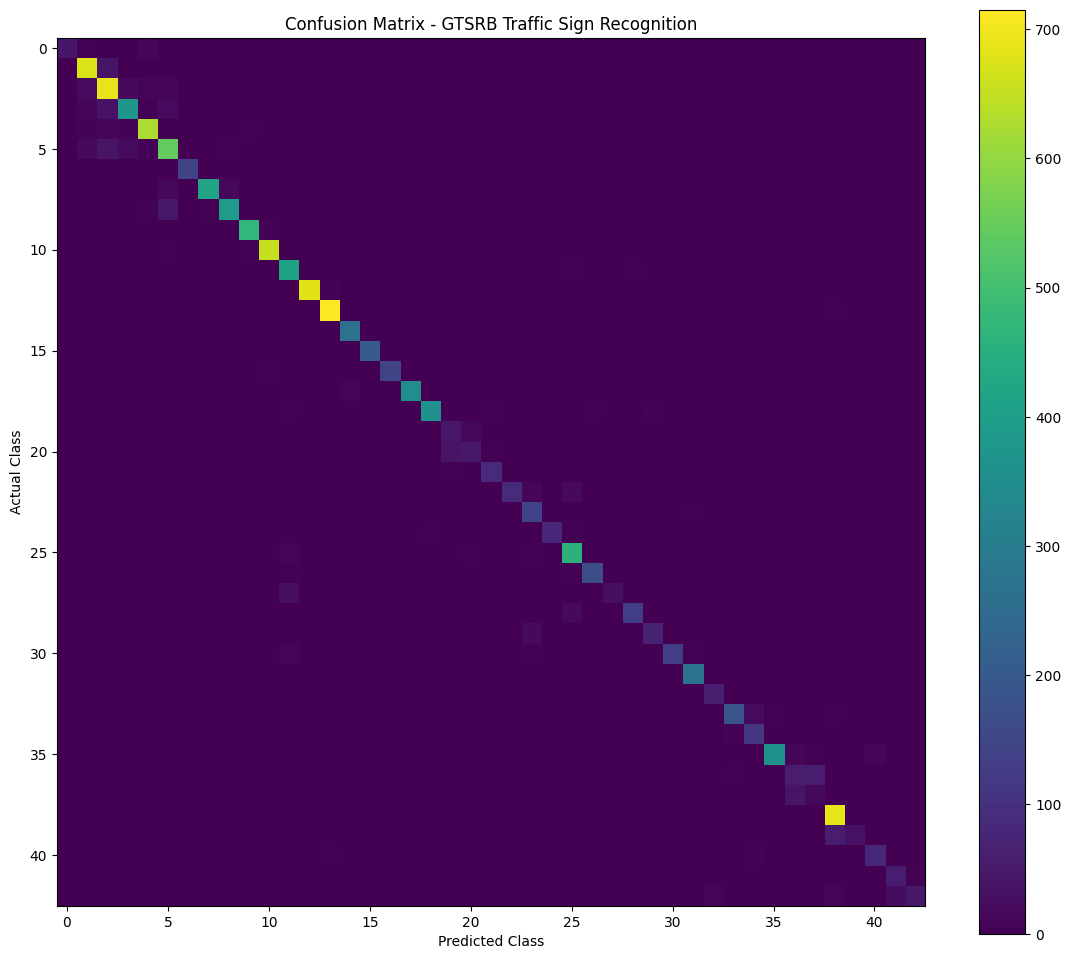

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
plt.imshow(cm)
plt.title("Confusion Matrix - GTSRB Traffic Sign Recognition")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()
plt.show()

In [24]:
signnames_df = pd.read_csv("/content/gtsrb/signnames.csv")

print(signnames_df.head())
print(signnames_df.columns)

   ClassId              SignName
0        0  Speed limit (20km/h)
1        1  Speed limit (30km/h)
2        2  Speed limit (50km/h)
3        3  Speed limit (60km/h)
4        4  Speed limit (70km/h)
Index(['ClassId', 'SignName'], dtype='object')


In [25]:
class_names = dict(
    zip(signnames_df["ClassId"], signnames_df["SignName"])
)

print(class_names[0])
print(class_names[14])
print(class_names[42])

Speed limit (20km/h)
Stop
End of no passing by vehicles over 3.5 metric tons


In [26]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

confusions = []

for actual in range(NUM_CLASSES):
    for predicted in range(NUM_CLASSES):
        if cm_no_diag[actual, predicted] > 0:
            confusions.append(
                (cm_no_diag[actual, predicted], actual, predicted)
            )

confusions.sort(reverse=True)

print("Top 15 misclassifications:\n")

for count, actual, predicted in confusions[:15]:
    print(
        f"Actual {actual} ({class_names[actual]})"
        f" -> Predicted {predicted} ({class_names[predicted]})"
        f" : {count} images"
    )

Top 15 misclassifications:

Actual 36 (Go straight or right) -> Predicted 37 (Go straight or left) : 58 images
Actual 39 (Keep left) -> Predicted 38 (Keep right) : 54 images
Actual 8 (Speed limit (120km/h)) -> Predicted 5 (Speed limit (80km/h)) : 46 images
Actual 37 (Go straight or left) -> Predicted 36 (Go straight or right) : 41 images
Actual 1 (Speed limit (30km/h)) -> Predicted 2 (Speed limit (50km/h)) : 41 images
Actual 5 (Speed limit (80km/h)) -> Predicted 2 (Speed limit (50km/h)) : 39 images
Actual 20 (Dangerous curve to the right) -> Predicted 19 (Dangerous curve to the left) : 38 images
Actual 3 (Speed limit (60km/h)) -> Predicted 2 (Speed limit (50km/h)) : 34 images
Actual 27 (Pedestrians) -> Predicted 11 (Right-of-way at the next intersection) : 30 images
Actual 42 (End of no passing by vehicles over 3.5 metric tons) -> Predicted 41 (End of no passing) : 23 images
Actual 3 (Speed limit (60km/h)) -> Predicted 5 (Speed limit (80km/h)) : 22 images
Actual 33 (Turn right ahead) -

In [30]:
def predict_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)

    image_batch = tf.expand_dims(image, axis=0)

    prediction = model.predict(image_batch, verbose=0)

    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100

    print("Image:", image_path)
    print("Predicted class:", predicted_class)
    print("Traffic sign:", class_names[predicted_class])
    print(f"Confidence: {confidence:.2f}%")

    return predicted_class, confidence


# Test with one training image
image_path = train_df["Path"].iloc[0]

predict_image(image_path)

Image: /content/gtsrb/Train/20/00020_00000_00000.png
Predicted class: 20
Traffic sign: Dangerous curve to the right
Confidence: 99.90%


(np.int64(20), np.float32(99.90296))

Image: /content/gtsrb/Train/20/00020_00000_00000.png
Predicted class: 20
Traffic sign: Dangerous curve to the right
Confidence: 99.90%


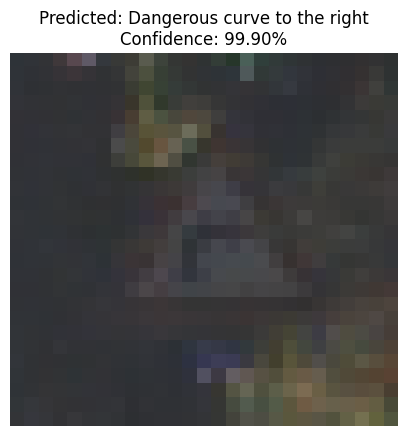

In [32]:
import matplotlib.pyplot as plt

image_path = train_df["Path"].iloc[0]

predicted_class, confidence = predict_image(image_path)

image = tf.io.read_file(image_path)
image = tf.image.decode_png(image, channels=3)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

In [33]:
sample_images = train_df["Path"].iloc[:5]

for image_path in sample_images:
    print("\n" + "="*50)
    predict_image(image_path)


Image: /content/gtsrb/Train/20/00020_00000_00000.png
Predicted class: 20
Traffic sign: Dangerous curve to the right
Confidence: 99.90%

Image: /content/gtsrb/Train/20/00020_00000_00001.png
Predicted class: 20
Traffic sign: Dangerous curve to the right
Confidence: 96.08%

Image: /content/gtsrb/Train/20/00020_00000_00002.png
Predicted class: 20
Traffic sign: Dangerous curve to the right
Confidence: 99.86%

Image: /content/gtsrb/Train/20/00020_00000_00003.png
Predicted class: 20
Traffic sign: Dangerous curve to the right
Confidence: 79.59%

Image: /content/gtsrb/Train/20/00020_00000_00004.png
Predicted class: 20
Traffic sign: Dangerous curve to the right
Confidence: 93.30%


Image: /content/gtsrb/Test/00000.png
Predicted class: 16
Traffic sign: Vehicles over 3.5 metric tons prohibited
Confidence: 100.00%


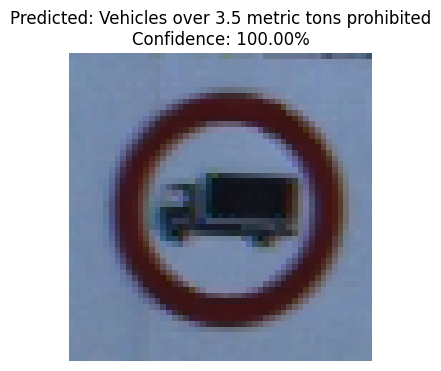

Image: /content/gtsrb/Test/00001.png
Predicted class: 1
Traffic sign: Speed limit (30km/h)
Confidence: 100.00%


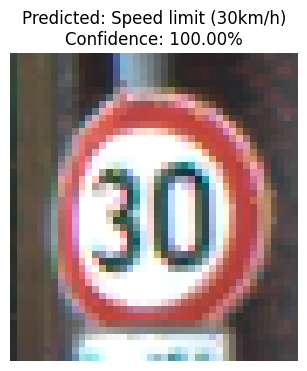

Image: /content/gtsrb/Test/00002.png
Predicted class: 38
Traffic sign: Keep right
Confidence: 100.00%


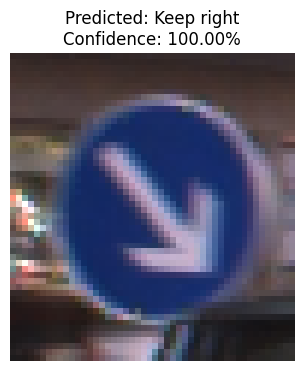

Image: /content/gtsrb/Test/00003.png
Predicted class: 33
Traffic sign: Turn right ahead
Confidence: 59.34%


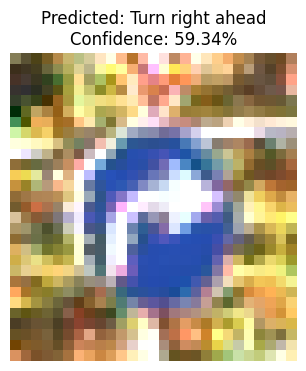

Image: /content/gtsrb/Test/00004.png
Predicted class: 11
Traffic sign: Right-of-way at the next intersection
Confidence: 100.00%


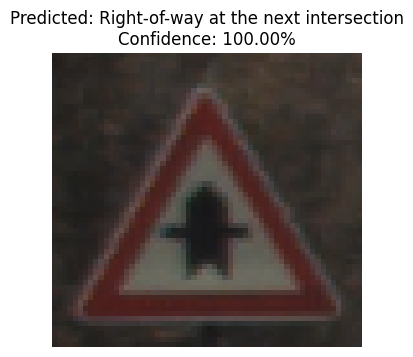

In [34]:
for i in range(5):
    image_path = test_df["Path"].iloc[i]

    predicted_class, confidence = predict_image(image_path)

    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(
        f"Predicted: {class_names[predicted_class]}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()

In [35]:
model.save("/content/traffic_sign_efficientnet.keras")

print("Model saved successfully.")

Model saved successfully.


Saving school_zone.png to school_zone.png
Image: school_zone.png
Predicted class: 28
Traffic sign: Children crossing
Confidence: 99.99%


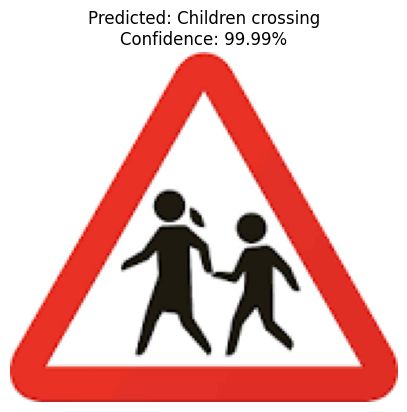

In [40]:
from google.colab import files
import matplotlib.pyplot as plt
import tensorflow as tf

# Upload image from your Desktop
uploaded = files.upload()

# Get uploaded image path
image_path = list(uploaded.keys())[0]

# Predict
predicted_class, confidence = predict_image(image_path)

# Read and display image
image = tf.io.read_file(image_path)
image = tf.image.decode_image(image, channels=3)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title(
    f"Predicted: {class_names[predicted_class]}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()